In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7f422b1834d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7f422af3c2f0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [3]:
response = llm.invoke("WHat is PTSD ?")
response.content

'**Post-Traumatic Stress Disorder (PTSD)** is a mental health condition that can develop after a person experiences or witnesses a traumatic event, such as:\n\n* Combat or war\n* Natural disasters (e.g., earthquakes, hurricanes)\n* Car accidents or other serious injuries\n* Physical or emotional abuse\n* Rape or sexual assault\n* Terrorism or violent crimes\n\nPTSD can affect anyone, regardless of age, background, or occupation. It\'s estimated that approximately 8% of the general population will experience PTSD at some point in their lives.\n\n**Symptoms of PTSD:**\n\n1. **Flashbacks**: Recurring memories or dreams related to the traumatic event.\n2. **Nightmares**: Vivid, disturbing dreams that can cause distress.\n3. **Avoidance**: Avoiding people, places, or activities that remind them of the traumatic event.\n4. **Hypervigilance**: Always being "on the lookout" for potential dangers.\n5. **Anxiety and fear**: Feeling anxious or fearful, even when there is no apparent danger.\n6. *

# **First Graph**





## Step 1: Define the schema

In [4]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    name: str
    message: str

## **Step 2: Create node functions**

In [5]:
def welcome(state:graph_schema) -> graph_schema:
    curr_name = state["name"]
    curr_message = state["message"]

    response = llm.invoke(f"My name is {curr_name}. {curr_message}").content

    state["message"] = f"Your message was {curr_message}. Here is my response {response}"

    return state    

## **Step 3: Create the state graph**

In [6]:
from langgraph.graph import StateGraph, START, END

# creating graph
graph = StateGraph(graph_schema)

# Adding node
graph.add_node("Welcome",welcome)

# Adding edges
graph.add_edge(START,"Welcome")
graph.add_edge("Welcome",END)

## Step 4: Complie the graph

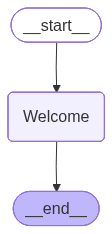

In [7]:
from IPython.display import Image,display
first_graph = graph.compile()

Image(first_graph.get_graph().draw_mermaid_png())

## **step 5: Run the graph**

In [8]:
first_graph.invoke({"name":"Atul","message":"When is the IPL 2026 starting ?"})

{'name': 'Atul',
 'message': "Your message was When is the IPL 2026 starting ?. Here is my response Hello Atul, \n\nThe Indian Premier League (IPL) 2026 schedule has not been officially announced yet. However, based on previous years' trends, it is likely to start in late March or early April 2026. I recommend checking the official IPL website or other reliable sources for the latest updates on the tournament schedule."}

In [9]:
first_graph.invoke({"name":"Atul","message":"What is the meaning of my name ?"})

{'name': 'Atul',
 'message': "Your message was What is the meaning of my name ?. Here is my response Hello Atul, \n\nThe name 'Atul' is of Sanskrit origin, and it means 'incomparable' or 'unique.' It is a popular name in many Indian languages, including Hindi, Marathi, and Gujarati. The name is derived from the Sanskrit word 'atula,' which means 'unmatched' or 'unequalled.' In essence, the name Atul signifies someone who is one-of-a-kind and exceptional in their own way.\n\nI hope that helps you understand the meaning and significance of your name, Atul."}

## This is called stateful graph, where the response are totally controlled by us. And hence, that's why we see response in name and message type of format. This we achieved using langgraph